In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
f_0 = 5e9
c0 = 299792458.0
lambda_ = c0 / f_0

boresight_gain = 2

Delta_EH = 500e-6
Delta_U = 50e-6

x_min, x_max = 0, 10
y_min, y_max = 0, 10
z_max = 3

cenarios = [1, 3]

# ============================================================
# GRADE PARA MAPA DE CALOR
# ============================================================
gradex = np.arange(x_min, x_max + 0.2, 0.2)
gradey = np.arange(y_min, y_max + 0.2, 0.2)

Nxg = len(gradex)
Nyg = len(gradey)

# ============================================================
# MONTE CARLO
# ============================================================
MC = 100

# ============================================================
# BAT ALGORITHM
# ============================================================
t_max = 200
n_bats = 100

# ============================================================
# RESULTADOS
# ============================================================
PTX = np.zeros((2, len(cenarios), MC))
SUCCESS = np.zeros((2, len(cenarios), MC))

# mapa médio: (modo, cenário, x, y, mc)
PRX_MAP = np.zeros((2, len(cenarios), Nxg, Nyg, MC))


# ============================================================
# FUNÇÕES
# ============================================================
def H_DMA(f_0, L, x):
    """
    Equivalente à função MATLAB H_DMA
    """
    c0 = 299792458.0
    lambda_ = c0 / f_0
    alpha = 0.5
    beta = 2 * np.pi / lambda_
    h = np.exp(-x * (alpha + 1j * beta))
    return h


def Do_Channels(Y, X, boresight_gain, lambda_):
    """
    Equivalente à função MATLAB Do_Channels

    Y: posições dos elementos da antena, shape (N,3)
    X: posições dos usuários/pontos, shape (M,3)

    saída:
    channel_vec: shape (N,M)
    """
    Y = np.atleast_2d(Y)
    X = np.atleast_2d(X)

    N = Y.shape[0]
    M = X.shape[0]

    channel_vec = np.zeros((N, M), dtype=complex)

    for i in range(N):
        for m in range(M):
            d = np.linalg.norm(Y[i, :] - X[m, :])
            dz = abs(Y[i, 2] - X[m, 2])
            gain = (dz / d) ** boresight_gain
            channel_vec[i, m] = gain * (lambda_ / (4 * np.pi * d)) * np.exp(-1j * 2 * np.pi * d / lambda_)

    return channel_vec


# ============================================================
# LOOP PRINCIPAL
# MODE = 0 -> digital
# MODE = 1 -> DMA
# ============================================================
for MODE in range(2):

    for c, cenario in enumerate(cenarios):

        for mc in range(MC):

            np.random.seed(mc)

            # ============================================================
            # USUÁRIOS
            # ============================================================
            if cenario == 1:
                k_loc = np.array([[4, 5, 1]], dtype=float)
            else:
                k_loc = np.array([[4, 5, 1],
                                  [5, 5, 1]], dtype=float)

            # ============================================================
            # ANTENA
            # ============================================================
            L = 0.2
            DMA_WG_dist = lambda_ / 2
            DMA_element_dist = lambda_ / 5

            RFC_num = int(np.floor(L / DMA_WG_dist))
            passive_num = int(np.floor(L / DMA_element_dist))

            N = RFC_num * passive_num

            DMA_loc = np.array([5, 5, z_max], dtype=float)

            DMA_element_loc = np.zeros((N, 3), dtype=float)

            for i in range(RFC_num):
                for j in range(passive_num):
                    idx = i * passive_num + j
                    DMA_element_loc[idx, :] = np.array([
                        DMA_loc[0] + (j + 1) * DMA_element_dist,
                        DMA_loc[1] + (i + 1) * DMA_WG_dist,
                        DMA_loc[2]
                    ])

            # ============================================================
            # CANAL DOS USUÁRIOS
            # no MATLAB: kk_loc = [k_loc(:,2) k_loc(:,1) k_loc(:,3)]
            # ============================================================
            kk_loc = np.column_stack((k_loc[:, 1], k_loc[:, 0], k_loc[:, 2]))
            channel_vec = Do_Channels(DMA_element_loc, kk_loc, boresight_gain, lambda_)

            # ============================================================
            # MATRIZ H (DMA)
            # ============================================================
            H = np.zeros((N, N), dtype=complex)
            for i in range(RFC_num):
                for l in range(passive_num):
                    idx = i * passive_num + l
                    H[idx, idx] = H_DMA(f_0, L, l * DMA_element_dist)

            # ============================================================
            # BA INIT
            # SOL shape = (N, n_bats)
            # cada coluna é um morcego
            # ============================================================
            SOL = np.random.randn(N, n_bats) + 1j * np.random.randn(N, n_bats)
            erro = np.zeros(n_bats)

            for i in range(n_bats):
                w = SOL[:, i]
                if MODE == 0:  # digital
                    erro[i] = np.sum(np.abs(w) ** 2)
                else:          # DMA
                    erro[i] = np.sum(np.abs(H @ w) ** 2)

            idx_best = np.argmin(erro)
            best_val = erro[idx_best]
            best = SOL[:, idx_best].copy()

            # ============================================================
            # BAT ALGORITHM
            # ============================================================
            for t in range(t_max):
                for b in range(n_bats):

                    w_old = SOL[:, b]
                    w_new = (
                        w_old
                        + 0.1 * (best - w_old)
                        + 0.05 * (np.random.randn(N) + 1j * np.random.randn(N))
                    )

                    # ====================================================
                    # DIGITAL
                    # ====================================================
                    if MODE == 0:
                        Ptx = np.sum(np.abs(w_new) ** 2)
                        P1 = np.abs(np.conj(channel_vec[:, 0]).T @ w_new) ** 2

                        if cenario == 1:
                            ok = (P1 >= Delta_EH)
                        else:
                            P2 = np.abs(np.conj(channel_vec[:, 1]).T @ w_new) ** 2
                            ok = (P1 >= Delta_EH) and (P2 <= Delta_U)

                    # ====================================================
                    # DMA
                    # ====================================================
                    else:
                        Hw = H @ w_new
                        Ptx = np.sum(np.abs(Hw) ** 2)
                        P1 = np.abs(np.conj(channel_vec[:, 0]).T @ Hw) ** 2

                        if cenario == 1:
                            ok = (P1 >= Delta_EH)
                        else:
                            P2 = np.abs(np.conj(channel_vec[:, 1]).T @ Hw) ** 2
                            ok = (P1 >= Delta_EH) and (P2 <= Delta_U)

                    if ok and (Ptx < erro[b]):
                        SOL[:, b] = w_new
                        erro[b] = Ptx

                        if Ptx < best_val:
                            best = w_new.copy()
                            best_val = Ptx

            # ============================================================
            # RESULTADOS
            # ============================================================
            PTX[MODE, c, mc] = best_val

            if MODE == 0:
                final_vec = best
            else:
                final_vec = H @ best

            if cenario == 1:
                SUCCESS[MODE, c, mc] = (
                    np.abs(np.conj(channel_vec[:, 0]).T @ final_vec) ** 2 >= Delta_EH
                )
            else:
                SUCCESS[MODE, c, mc] = (
                    (np.abs(np.conj(channel_vec[:, 0]).T @ final_vec) ** 2 >= Delta_EH)
                    and
                    (np.abs(np.conj(channel_vec[:, 1]).T @ final_vec) ** 2 <= Delta_U)
                )

            # ============================================================
            # MAPA DE CALOR
            # ============================================================
            PRX = np.zeros((Nxg, Nyg))

            for ix in range(Nxg):
                for iy in range(Nyg):
                    # usa z = 1 para ficar no plano dos usuários
                    test_point = np.array([gradey[iy], gradex[ix], 1.0])
                    ctest = Do_Channels(DMA_element_loc, test_point, boresight_gain, lambda_).flatten()

                    PRX[ix, iy] = np.abs(np.conj(ctest).T @ final_vec) ** 2

            # normalização em dB
            PRX = PRX / np.max(PRX)
            PRX = 10 * np.log10(PRX)
            PRX[PRX < -25] = -25

            PRX_MAP[MODE, c, :, :, mc] = PRX

            total = 2 * len(cenarios) * MC
            atual = MODE * len(cenarios) * MC + c * MC + (mc + 1)
            print(f"Progresso: {atual}/{total} ({100*atual/total:.1f}%) | MODE {MODE+1} | Cen {cenario} | MC {mc+1}")

# ============================================================
# RESULTADOS
# ============================================================
print("\n====== RESULTADOS ======\n")

for MODE in range(2):
    if MODE == 0:
        print("--- DIGITAL ---")
    else:
        print("--- DMA ---")

    for c, cenario in enumerate(cenarios):
        print(f"Cenario {cenario}:")
        print(f"PTX medio = {np.mean(PTX[MODE, c, :]):.2e}")
        print(f"Sucesso = {100 * np.mean(SUCCESS[MODE, c, :]):.2f} %")



# ============================================================
# MAPAS DE CALOR MÉDIOS
# ============================================================
for MODE in range(2):
    for c, cenario in enumerate(cenarios):

        PRX_mean = np.mean(PRX_MAP[MODE, c, :, :, :], axis=2)

        plt.figure(figsize=(7, 5))
        contour = plt.contourf(gradex, gradey, PRX_mean.T, levels=12, cmap='jet')
        plt.colorbar(contour)
        plt.xlabel('X')
        plt.ylabel('Y')

        if MODE == 0:
            metodo = 'Beamforming Digital'
        else:
            metodo = 'DMA'

        plt.title(f'{metodo} - Mapa de calor medio - Cenario {cenario}')

        if cenario == 1:
            k_loc = np.array([[4, 5, 1]], dtype=float)
        else:
            k_loc = np.array([[4, 5, 1],
                              [5, 5, 1]], dtype=float)

        plt.plot(k_loc[:, 0], k_loc[:, 1], 'ko', markersize=8)

        for u in range(k_loc.shape[0]):
            plt.text(k_loc[u, 0] + 0.15, k_loc[u, 1], f'User {u+1}',
                     color='k', fontweight='bold')

        plt.show()

Progresso: 1/400 (0.2%) | MODE 1 | Cen 1 | MC 1
Progresso: 2/400 (0.5%) | MODE 1 | Cen 1 | MC 2
Progresso: 3/400 (0.8%) | MODE 1 | Cen 1 | MC 3
Progresso: 4/400 (1.0%) | MODE 1 | Cen 1 | MC 4
Progresso: 5/400 (1.2%) | MODE 1 | Cen 1 | MC 5
Progresso: 6/400 (1.5%) | MODE 1 | Cen 1 | MC 6
Progresso: 7/400 (1.8%) | MODE 1 | Cen 1 | MC 7
Progresso: 8/400 (2.0%) | MODE 1 | Cen 1 | MC 8
Progresso: 9/400 (2.2%) | MODE 1 | Cen 1 | MC 9
Progresso: 10/400 (2.5%) | MODE 1 | Cen 1 | MC 10
Progresso: 11/400 (2.8%) | MODE 1 | Cen 1 | MC 11
Progresso: 12/400 (3.0%) | MODE 1 | Cen 1 | MC 12
Progresso: 13/400 (3.2%) | MODE 1 | Cen 1 | MC 13
Progresso: 14/400 (3.5%) | MODE 1 | Cen 1 | MC 14
Progresso: 15/400 (3.8%) | MODE 1 | Cen 1 | MC 15
Progresso: 16/400 (4.0%) | MODE 1 | Cen 1 | MC 16
Progresso: 17/400 (4.2%) | MODE 1 | Cen 1 | MC 17
Progresso: 18/400 (4.5%) | MODE 1 | Cen 1 | MC 18
Progresso: 19/400 (4.8%) | MODE 1 | Cen 1 | MC 19
Progresso: 20/400 (5.0%) | MODE 1 | Cen 1 | MC 20
Progresso: 21/400 


===== RESULTADO FINAL =====
Método: Beamforming Digital
Cenário: 1
Melhor PTX = 2.6428e+01
Potência no User 1 = 6.3498e-04
Restrição EH atendida: True

===== RESULTADO FINAL =====
Método: DMA
Cenário: 1
Melhor PTX = 2.4075e+01
Potência no User 1 = 5.7495e-04
Restrição EH atendida: True


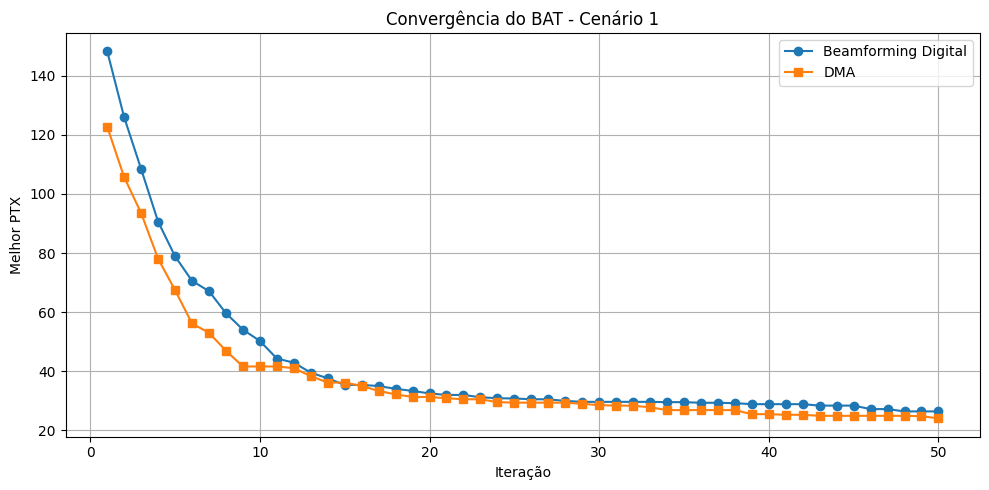

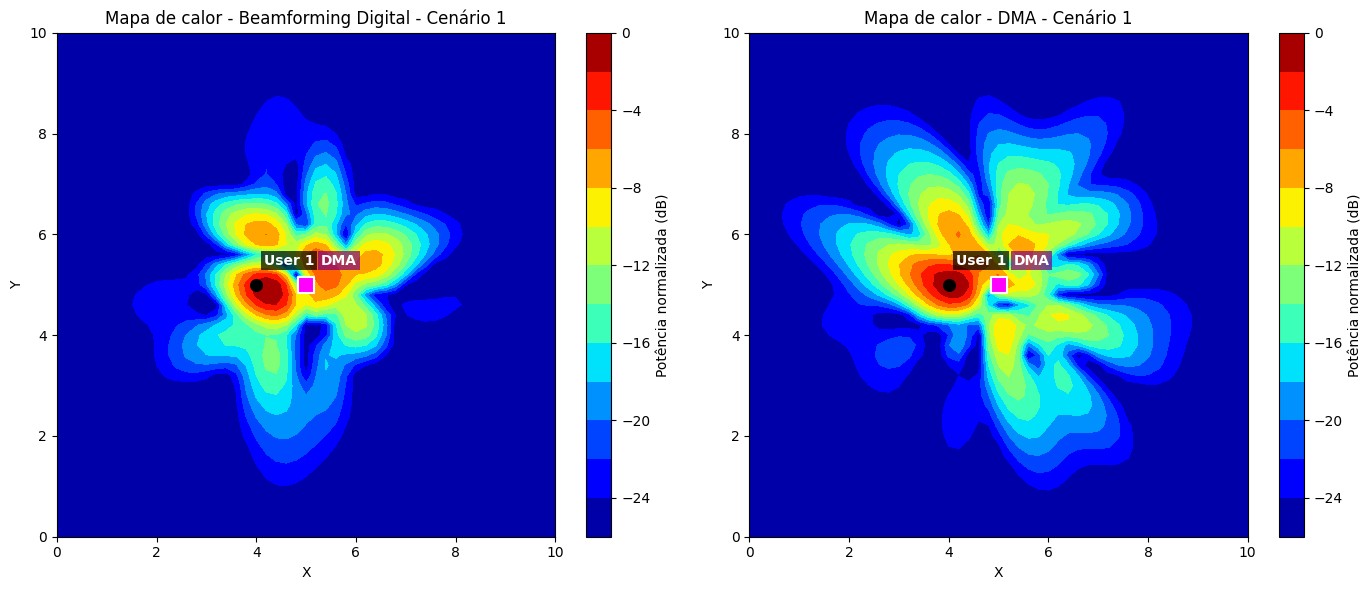

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO GERAL
# ============================================================
f_0 = 5e9
c0 = 299792458.0
lambda_ = c0 / f_0

boresight_gain = 2
Delta_EH = 500e-6
z_max = 3

# cenário 1: um usuário
cenario = 1

# parâmetros do BAT
t_max = 50
n_bats = 30

# grade do mapa de calor
x_min, x_max = 0, 10
y_min, y_max = 0, 10
passo = 0.2

gradex = np.arange(x_min, x_max + passo, passo)
gradey = np.arange(y_min, y_max + passo, passo)

# semente fixa
np.random.seed(1)

# ============================================================
# FUNÇÕES
# ============================================================
def H_DMA(f_0, x):
    c0 = 299792458.0
    lambda_ = c0 / f_0
    alpha = 0.5
    beta = 2 * np.pi / lambda_
    return np.exp(-x * (alpha + 1j * beta))

def do_channels(Y, X, boresight_gain, lambda_):
    Y = np.atleast_2d(Y)
    X = np.atleast_2d(X)

    N = Y.shape[0]
    M = X.shape[0]
    channel_vec = np.zeros((N, M), dtype=complex)

    for i in range(N):
        for m in range(M):
            d = np.linalg.norm(Y[i] - X[m])
            dz = abs(Y[i, 2] - X[m, 2])
            gain = (dz / d) ** boresight_gain
            channel_vec[i, m] = gain * (lambda_ / (4 * np.pi * d)) * np.exp(-1j * 2 * np.pi * d / lambda_)

    return channel_vec

# ============================================================
# USUÁRIO - CENÁRIO 1
# ============================================================
k_loc = np.array([
    [4.0, 5.0, 1.0]   # User 1
])

# ============================================================
# GEOMETRIA DA ANTENA
# ============================================================
L = 0.2
DMA_WG_dist = lambda_ / 2
DMA_element_dist = lambda_ / 5

RFC_num = int(np.floor(L / DMA_WG_dist))
passive_num = int(np.floor(L / DMA_element_dist))
N = RFC_num * passive_num

DMA_loc = np.array([5.0, 5.0, z_max])

DMA_element_loc = np.zeros((N, 3))
for i in range(RFC_num):
    for j in range(passive_num):
        idx = i * passive_num + j
        DMA_element_loc[idx] = [
            DMA_loc[0] + (j + 1) * DMA_element_dist,
            DMA_loc[1] + (i + 1) * DMA_WG_dist,
            DMA_loc[2]
        ]

# ============================================================
# CANAL DO USUÁRIO
# ============================================================
channel_vec = do_channels(DMA_element_loc, k_loc, boresight_gain, lambda_)

# ============================================================
# MATRIZ H PARA O CASO DMA
# ============================================================
H = np.zeros((N, N), dtype=complex)
for i in range(RFC_num):
    for l in range(passive_num):
        idx = i * passive_num + l
        H[idx, idx] = H_DMA(f_0, l * DMA_element_dist)

# ============================================================
# FUNÇÃO QUE EXECUTA O BAT PARA UM MÉTODO
# MODE = 0 -> Beamforming Digital
# MODE = 1 -> DMA
# ============================================================
def run_bat_mode(MODE, channel_vec, H, N, t_max, n_bats, Delta_EH):
    SOL = np.random.randn(N, n_bats) + 1j * np.random.randn(N, n_bats)
    erro = np.zeros(n_bats)

    for b in range(n_bats):
        w = SOL[:, b]
        if MODE == 0:
            erro[b] = np.sum(np.abs(w) ** 2)
        else:
            erro[b] = np.sum(np.abs(H @ w) ** 2)

    idx_best = np.argmin(erro)
    best = SOL[:, idx_best].copy()
    best_val = erro[idx_best]

    historico_best = []

    for t in range(t_max):
        for b in range(n_bats):
            w_old = SOL[:, b]

            w_new = (
                w_old
                + 0.1 * (best - w_old)
                + 0.05 * (np.random.randn(N) + 1j * np.random.randn(N))
            )

            if MODE == 0:
                final_test = w_new
            else:
                final_test = H @ w_new

            Ptx = np.sum(np.abs(final_test) ** 2)
            P1 = np.abs(np.conj(channel_vec[:, 0]).T @ final_test) ** 2

            ok = (P1 >= Delta_EH)

            if ok and (Ptx < erro[b]):
                SOL[:, b] = w_new
                erro[b] = Ptx

                if Ptx < best_val:
                    best = w_new.copy()
                    best_val = Ptx

        historico_best.append(best_val)

    if MODE == 0:
        final_vec = best
        metodo = "Beamforming Digital"
    else:
        final_vec = H @ best
        metodo = "DMA"

    P1_final = np.abs(np.conj(channel_vec[:, 0]).T @ final_vec) ** 2

    return {
        "metodo": metodo,
        "best_val": best_val,
        "final_vec": final_vec,
        "historico_best": historico_best,
        "P1_final": P1_final,
    }

# ============================================================
# EXECUTA OS DOIS MÉTODOS
# ============================================================
np.random.seed(1)
resultado_digital = run_bat_mode(
    MODE=0,
    channel_vec=channel_vec,
    H=H,
    N=N,
    t_max=t_max,
    n_bats=n_bats,
    Delta_EH=Delta_EH
)

np.random.seed(1)
resultado_dma = run_bat_mode(
    MODE=1,
    channel_vec=channel_vec,
    H=H,
    N=N,
    t_max=t_max,
    n_bats=n_bats,
    Delta_EH=Delta_EH
)

# ============================================================
# IMPRESSÃO DOS RESULTADOS
# ============================================================
for resultado in [resultado_digital, resultado_dma]:
    print("\n===== RESULTADO FINAL =====")
    print("Método:", resultado["metodo"])
    print("Cenário: 1")
    print(f"Melhor PTX = {resultado['best_val']:.4e}")
    print(f"Potência no User 1 = {resultado['P1_final']:.4e}")
    print("Restrição EH atendida:", resultado["P1_final"] >= Delta_EH)

# ============================================================
# FUNÇÃO PARA GERAR MAPA DE CALOR
# ============================================================
def compute_heatmap(final_vec, DMA_element_loc, gradex, gradey, boresight_gain, lambda_):
    PRX = np.zeros((len(gradex), len(gradey)))

    for ix in range(len(gradex)):
        for iy in range(len(gradey)):
            test_point = np.array([gradex[ix], gradey[iy], 1.0])
            ctest = do_channels(DMA_element_loc, test_point, boresight_gain, lambda_).flatten()
            PRX[ix, iy] = np.abs(np.conj(ctest).T @ final_vec) ** 2

    PRX = PRX / np.max(PRX)

    eps = 1e-12
    PRX_db = 10 * np.log10(np.maximum(PRX, eps))
    PRX_db[PRX_db < -25] = -25
    return PRX_db

PRX_db_digital = compute_heatmap(
    resultado_digital["final_vec"],
    DMA_element_loc,
    gradex,
    gradey,
    boresight_gain,
    lambda_
)

PRX_db_dma = compute_heatmap(
    resultado_dma["final_vec"],
    DMA_element_loc,
    gradex,
    gradey,
    boresight_gain,
    lambda_
)

# ============================================================
# FIGURA 1: CONVERGÊNCIA DOS DOIS MÉTODOS
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, t_max + 1), resultado_digital["historico_best"], marker='o', label='Beamforming Digital')
plt.plot(range(1, t_max + 1), resultado_dma["historico_best"], marker='s', label='DMA')
plt.xlabel("Iteração")
plt.ylabel("Melhor PTX")
plt.title("Convergência do BAT - Cenário 1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# FIGURA 2: MAPAS DE CALOR LADO A LADO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------
# Mapa Beamforming Digital
# -------------------------
contour1 = axes[0].contourf(gradex, gradey, PRX_db_digital.T, levels=12, cmap='jet')
fig.colorbar(contour1, ax=axes[0], label='Potência normalizada (dB)')
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("Mapa de calor - Beamforming Digital - Cenário 1")
axes[0].set_xlim([x_min, x_max])
axes[0].set_ylim([y_min, y_max])

axes[0].scatter(k_loc[:, 0], k_loc[:, 1], c='black', s=70, marker='o', zorder=5)

axes[0].text(
    k_loc[0, 0] + 0.15, k_loc[0, 1] + 0.40, 'User 1',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

axes[0].scatter(
    DMA_loc[0], DMA_loc[1],
    c='magenta', s=140, marker='s',
    edgecolors='white', linewidths=1.5, zorder=4
)

axes[0].text(
    DMA_loc[0] + 0.30, DMA_loc[1] + 0.40, 'DMA',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='purple', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

# -------------------------
# Mapa DMA
# -------------------------
contour2 = axes[1].contourf(gradex, gradey, PRX_db_dma.T, levels=12, cmap='jet')
fig.colorbar(contour2, ax=axes[1], label='Potência normalizada (dB)')
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title("Mapa de calor - DMA - Cenário 1")
axes[1].set_xlim([x_min, x_max])
axes[1].set_ylim([y_min, y_max])

axes[1].scatter(k_loc[:, 0], k_loc[:, 1], c='black', s=70, marker='o', zorder=5)

axes[1].text(
    k_loc[0, 0] + 0.15, k_loc[0, 1] + 0.40, 'User 1',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

axes[1].scatter(
    DMA_loc[0], DMA_loc[1],
    c='magenta', s=140, marker='s',
    edgecolors='white', linewidths=1.5, zorder=4
)

axes[1].text(
    DMA_loc[0] + 0.30, DMA_loc[1] + 0.40, 'DMA',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='purple', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

plt.tight_layout()
plt.show()


===== RESULTADO FINAL =====
Método: Beamforming Digital
Cenário: 3
Melhor PTX = 1.4031e+02
Potência no User 1 = 5.7399e-04
Potência no User 2 = 2.0899e-05
Restrição EH atendida: True
Restrição User 2 atendida: True

===== RESULTADO FINAL =====
Método: DMA
Cenário: 3
Melhor PTX = 7.2536e+01
Potência no User 1 = 6.1477e-04
Potência no User 2 = 2.2671e-05
Restrição EH atendida: True
Restrição User 2 atendida: True


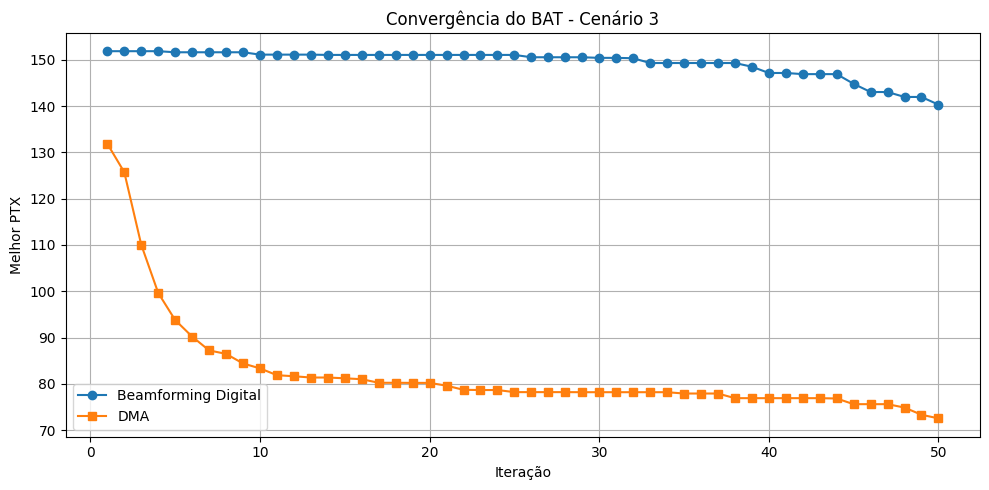

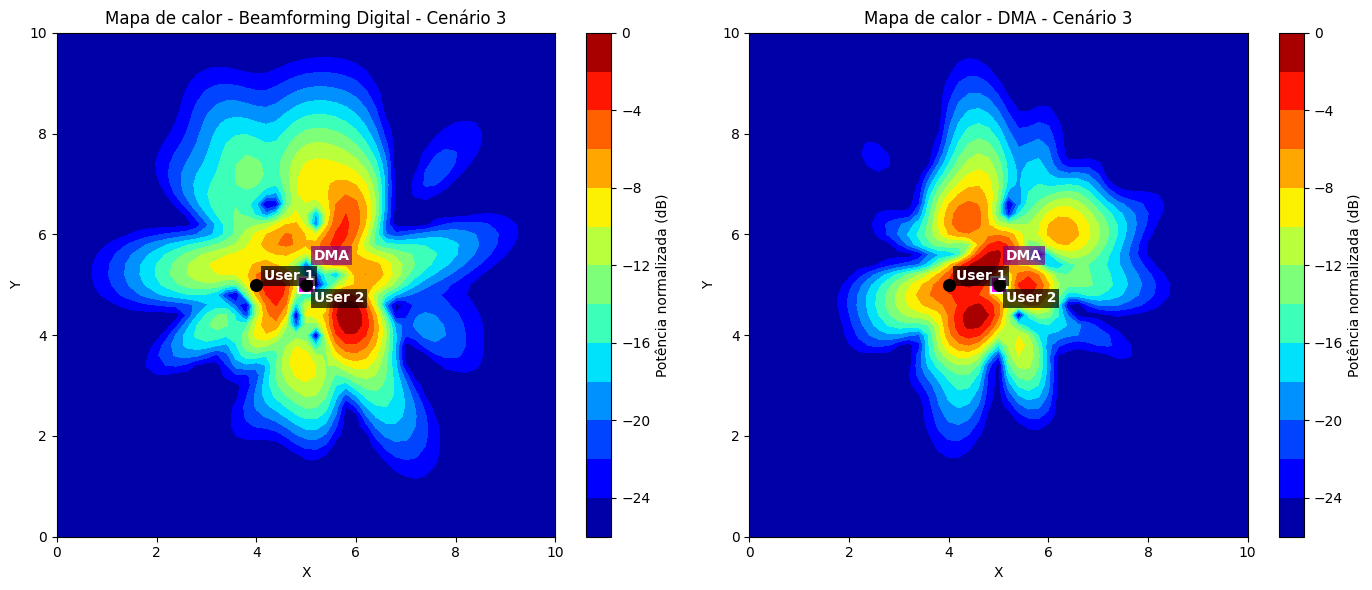

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURAÇÃO GERAL
# ============================================================
f_0 = 5e9
c0 = 299792458.0
lambda_ = c0 / f_0

boresight_gain = 2
Delta_EH = 500e-6
Delta_U = 50e-6
z_max = 3

# cenário 3: dois usuários
cenario = 3

# parâmetros do BAT
t_max = 50
n_bats = 30

# grade do mapa de calor
x_min, x_max = 0, 10
y_min, y_max = 0, 10
passo = 0.2

gradex = np.arange(x_min, x_max + passo, passo)
gradey = np.arange(y_min, y_max + passo, passo)

# semente fixa para reprodutibilidade
np.random.seed(1)

# ============================================================
# FUNÇÕES
# ============================================================
def H_DMA(f_0, x):
    c0 = 299792458.0
    lambda_ = c0 / f_0
    alpha = 0.5
    beta = 2 * np.pi / lambda_
    return np.exp(-x * (alpha + 1j * beta))

def do_channels(Y, X, boresight_gain, lambda_):
    Y = np.atleast_2d(Y)
    X = np.atleast_2d(X)

    N = Y.shape[0]
    M = X.shape[0]
    channel_vec = np.zeros((N, M), dtype=complex)

    for i in range(N):
        for m in range(M):
            d = np.linalg.norm(Y[i] - X[m])
            dz = abs(Y[i, 2] - X[m, 2])
            gain = (dz / d) ** boresight_gain
            channel_vec[i, m] = gain * (lambda_ / (4 * np.pi * d)) * np.exp(-1j * 2 * np.pi * d / lambda_)

    return channel_vec

# ============================================================
# USUÁRIOS - CENÁRIO 3
# ============================================================
k_loc = np.array([
    [4.0, 5.0, 1.0],   # User 1
    [5.0, 5.0, 1.0]    # User 2
])

# ============================================================
# GEOMETRIA DA ANTENA
# ============================================================
L = 0.2
DMA_WG_dist = lambda_ / 2
DMA_element_dist = lambda_ / 5

RFC_num = int(np.floor(L / DMA_WG_dist))
passive_num = int(np.floor(L / DMA_element_dist))
N = RFC_num * passive_num

DMA_loc = np.array([5.0, 5.0, z_max])

DMA_element_loc = np.zeros((N, 3))
for i in range(RFC_num):
    for j in range(passive_num):
        idx = i * passive_num + j
        DMA_element_loc[idx] = [
            DMA_loc[0] + (j + 1) * DMA_element_dist,
            DMA_loc[1] + (i + 1) * DMA_WG_dist,
            DMA_loc[2]
        ]

# ============================================================
# CANAL DOS USUÁRIOS
# convenção: [x, y, z]
# ============================================================
channel_vec = do_channels(DMA_element_loc, k_loc, boresight_gain, lambda_)

# ============================================================
# MATRIZ H PARA O CASO DMA
# ============================================================
H = np.zeros((N, N), dtype=complex)
for i in range(RFC_num):
    for l in range(passive_num):
        idx = i * passive_num + l
        H[idx, idx] = H_DMA(f_0, l * DMA_element_dist)

# ============================================================
# FUNÇÃO QUE EXECUTA O BAT PARA UM MÉTODO
# MODE = 0 -> Beamforming Digital
# MODE = 1 -> DMA
# ============================================================
def run_bat_mode(MODE, channel_vec, H, N, t_max, n_bats, Delta_EH, Delta_U):
    SOL = np.random.randn(N, n_bats) + 1j * np.random.randn(N, n_bats)
    erro = np.zeros(n_bats)

    for b in range(n_bats):
        w = SOL[:, b]
        if MODE == 0:
            erro[b] = np.sum(np.abs(w) ** 2)
        else:
            erro[b] = np.sum(np.abs(H @ w) ** 2)

    idx_best = np.argmin(erro)
    best = SOL[:, idx_best].copy()
    best_val = erro[idx_best]

    historico_best = []

    for t in range(t_max):
        for b in range(n_bats):
            w_old = SOL[:, b]

            w_new = (
                w_old
                + 0.1 * (best - w_old)
                + 0.05 * (np.random.randn(N) + 1j * np.random.randn(N))
            )

            if MODE == 0:
                final_test = w_new
            else:
                final_test = H @ w_new

            Ptx = np.sum(np.abs(final_test) ** 2)
            P1 = np.abs(np.conj(channel_vec[:, 0]).T @ final_test) ** 2
            P2 = np.abs(np.conj(channel_vec[:, 1]).T @ final_test) ** 2

            ok = (P1 >= Delta_EH) and (P2 <= Delta_U)

            if ok and (Ptx < erro[b]):
                SOL[:, b] = w_new
                erro[b] = Ptx

                if Ptx < best_val:
                    best = w_new.copy()
                    best_val = Ptx

        historico_best.append(best_val)

    if MODE == 0:
        final_vec = best
        metodo = "Beamforming Digital"
    else:
        final_vec = H @ best
        metodo = "DMA"

    P1_final = np.abs(np.conj(channel_vec[:, 0]).T @ final_vec) ** 2
    P2_final = np.abs(np.conj(channel_vec[:, 1]).T @ final_vec) ** 2

    return {
        "metodo": metodo,
        "best_val": best_val,
        "final_vec": final_vec,
        "historico_best": historico_best,
        "P1_final": P1_final,
        "P2_final": P2_final,
    }

# ============================================================
# EXECUTA OS DOIS MÉTODOS
# ============================================================
# reseta semente para tornar as comparações mais consistentes
np.random.seed(1)
resultado_digital = run_bat_mode(
    MODE=0,
    channel_vec=channel_vec,
    H=H,
    N=N,
    t_max=t_max,
    n_bats=n_bats,
    Delta_EH=Delta_EH,
    Delta_U=Delta_U
)

np.random.seed(1)
resultado_dma = run_bat_mode(
    MODE=1,
    channel_vec=channel_vec,
    H=H,
    N=N,
    t_max=t_max,
    n_bats=n_bats,
    Delta_EH=Delta_EH,
    Delta_U=Delta_U
)

# ============================================================
# IMPRESSÃO DOS RESULTADOS
# ============================================================
for resultado in [resultado_digital, resultado_dma]:
    print("\n===== RESULTADO FINAL =====")
    print("Método:", resultado["metodo"])
    print("Cenário: 3")
    print(f"Melhor PTX = {resultado['best_val']:.4e}")
    print(f"Potência no User 1 = {resultado['P1_final']:.4e}")
    print(f"Potência no User 2 = {resultado['P2_final']:.4e}")
    print("Restrição EH atendida:", resultado["P1_final"] >= Delta_EH)
    print("Restrição User 2 atendida:", resultado["P2_final"] <= Delta_U)

# ============================================================
# FUNÇÃO PARA GERAR MAPA DE CALOR
# ============================================================
def compute_heatmap(final_vec, DMA_element_loc, gradex, gradey, boresight_gain, lambda_):
    PRX = np.zeros((len(gradex), len(gradey)))

    for ix in range(len(gradex)):
        for iy in range(len(gradey)):
            test_point = np.array([gradex[ix], gradey[iy], 1.0])
            ctest = do_channels(DMA_element_loc, test_point, boresight_gain, lambda_).flatten()
            PRX[ix, iy] = np.abs(np.conj(ctest).T @ final_vec) ** 2

    PRX = PRX / np.max(PRX)

    eps = 1e-12
    PRX_db = 10 * np.log10(np.maximum(PRX, eps))
    PRX_db[PRX_db < -25] = -25
    return PRX_db

PRX_db_digital = compute_heatmap(
    resultado_digital["final_vec"],
    DMA_element_loc,
    gradex,
    gradey,
    boresight_gain,
    lambda_
)

PRX_db_dma = compute_heatmap(
    resultado_dma["final_vec"],
    DMA_element_loc,
    gradex,
    gradey,
    boresight_gain,
    lambda_
)

# ============================================================
# FIGURA 1: CONVERGÊNCIA DOS DOIS MÉTODOS
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, t_max + 1), resultado_digital["historico_best"], marker='o', label='Beamforming Digital')
plt.plot(range(1, t_max + 1), resultado_dma["historico_best"], marker='s', label='DMA')
plt.xlabel("Iteração")
plt.ylabel("Melhor PTX")
plt.title("Convergência do BAT - Cenário 3")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# FIGURA 2: MAPAS DE CALOR LADO A LADO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -------------------------
# Mapa Beamforming Digital
# -------------------------
contour1 = axes[0].contourf(gradex, gradey, PRX_db_digital.T, levels=12, cmap='jet')
fig.colorbar(contour1, ax=axes[0], label='Potência normalizada (dB)')
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].set_title("Mapa de calor - Beamforming Digital - Cenário 3")
axes[0].set_xlim([x_min, x_max])
axes[0].set_ylim([y_min, y_max])

axes[0].scatter(k_loc[:, 0], k_loc[:, 1], c='black', s=70, marker='o', zorder=5)

axes[0].text(
    k_loc[0, 0] + 0.15, k_loc[0, 1] + 0.10, 'User 1',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

axes[0].text(
    k_loc[1, 0] + 0.15, k_loc[1, 1] - 0.35, 'User 2',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

axes[0].scatter(
    DMA_loc[0], DMA_loc[1],
    c='magenta', s=140, marker='s',
    edgecolors='white', linewidths=1.5, zorder=4
)

axes[0].text(
    DMA_loc[0] + 0.15, DMA_loc[1] + 0.50, 'DMA',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='purple', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

# -------------------------
# Mapa DMA
# -------------------------
contour2 = axes[1].contourf(gradex, gradey, PRX_db_dma.T, levels=12, cmap='jet')
fig.colorbar(contour2, ax=axes[1], label='Potência normalizada (dB)')
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_title("Mapa de calor - DMA - Cenário 3")
axes[1].set_xlim([x_min, x_max])
axes[1].set_ylim([y_min, y_max])

axes[1].scatter(k_loc[:, 0], k_loc[:, 1], c='black', s=70, marker='o', zorder=5)

axes[1].text(
    k_loc[0, 0] + 0.15, k_loc[0, 1] + 0.10, 'User 1',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

axes[1].text(
    k_loc[1, 0] + 0.15, k_loc[1, 1] - 0.35, 'User 2',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

axes[1].scatter(
    DMA_loc[0], DMA_loc[1],
    c='magenta', s=140, marker='s',
    edgecolors='white', linewidths=1.5, zorder=4
)

axes[1].text(
    DMA_loc[0] +0.15 , DMA_loc[1] + 0.50, 'DMA',
    color='white', fontsize=10, fontweight='bold',
    bbox=dict(facecolor='purple', alpha=0.7, edgecolor='none', pad=2),
    zorder=6
)

plt.tight_layout()
plt.show()